108386


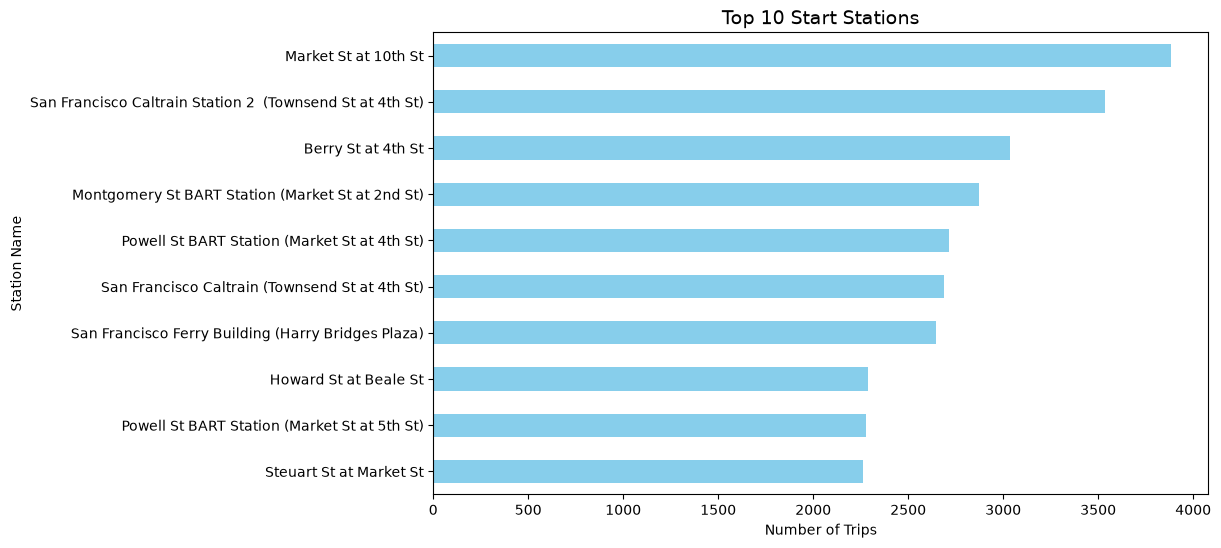

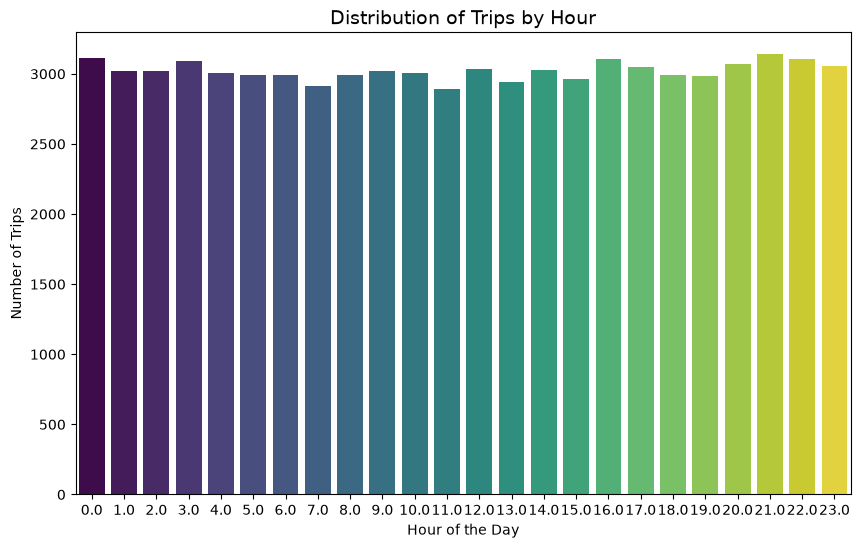

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('preprocessing/cleaned_fordgobike_data.csv')

print(df['start_time'].isnull().sum())

df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
df['hour'] = df['end_time'].dt.hour
df['day_of_week'] = df['end_time'].dt.day_name()

plt.figure(figsize=(10, 6))
df['start_station_name'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Start Stations', fontsize=14)
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='hour', hue='hour', legend=False, palette='viridis')
plt.title('Distribution of Trips by Hour', fontsize=14)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('preprocessing/cleaned_fordgobike_data.csv')

df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
df['duration_sec'] = pd.to_numeric(df['duration_sec'], errors='coerce')

df['start_time'] = df['end_time'] - pd.to_timedelta(df['duration_sec'], unit='s')

df['start_hour'] = df['start_time'].dt.hour
df['start_day'] = df['start_time'].dt.day_name()
df['duration_min'] = df['duration_sec'] / 60

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']




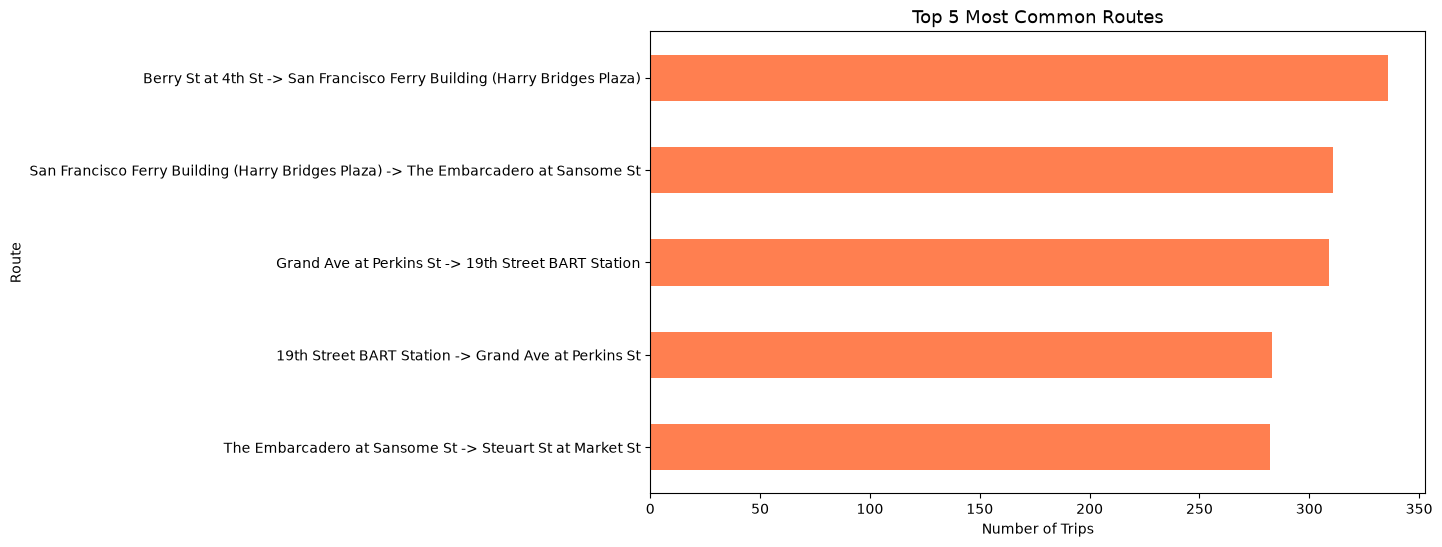

In [9]:
df['route'] = df['start_station_name'] + ' -> ' + df['end_station_name']
plt.figure(figsize=(10, 6))
df['route'].value_counts().head(5).plot(kind='barh', color='coral')
plt.title('Top 5 Most Common Routes', fontsize=13)
plt.xlabel('Number of Trips')
plt.ylabel('Route')
plt.gca().invert_yaxis()
plt.show()

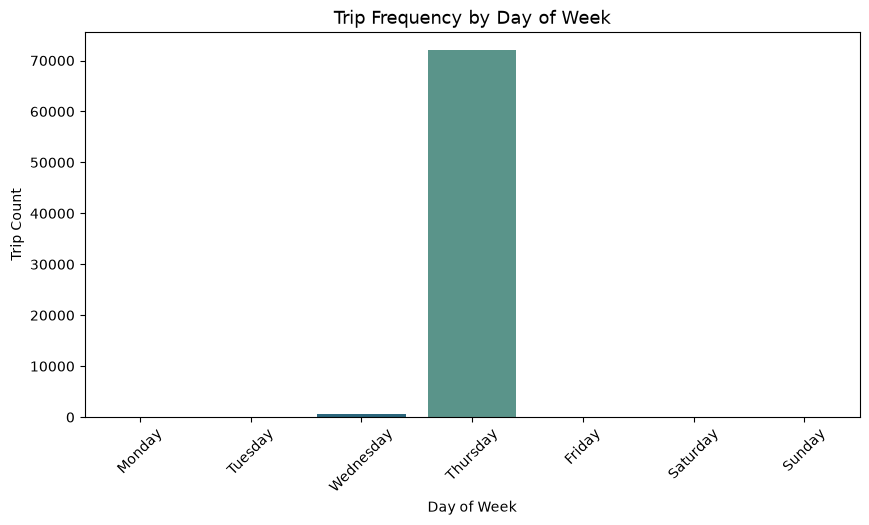

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='start_day', order=days_order, hue='start_day', legend=False, palette='crest')
plt.title('Trip Frequency by Day of Week', fontsize=13)
plt.xlabel('Day of Week')
plt.ylabel('Trip Count')
plt.xticks(rotation=45)
plt.show()

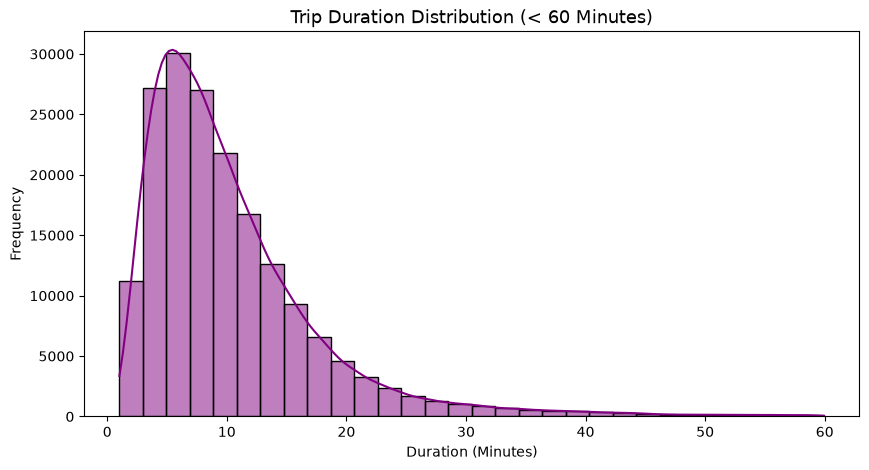

In [11]:
plt.figure(figsize=(10, 5))
valid_duration = df[df['duration_min'] <= 60]
sns.histplot(valid_duration['duration_min'], bins=30, kde=True, color='purple')
plt.title('Trip Duration Distribution (< 60 Minutes)', fontsize=13)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

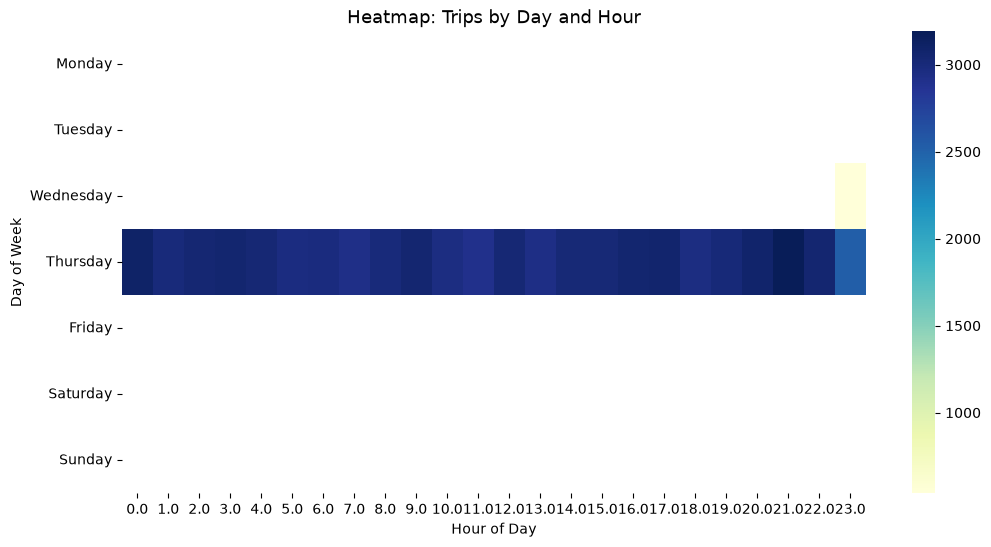

In [12]:
pivot_time = df.pivot_table(index='start_day', columns='start_hour', values='duration_sec', aggfunc='count').reindex(days_order)
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_time, cmap='YlGnBu', fmt='g')
plt.title('Heatmap: Trips by Day and Hour', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

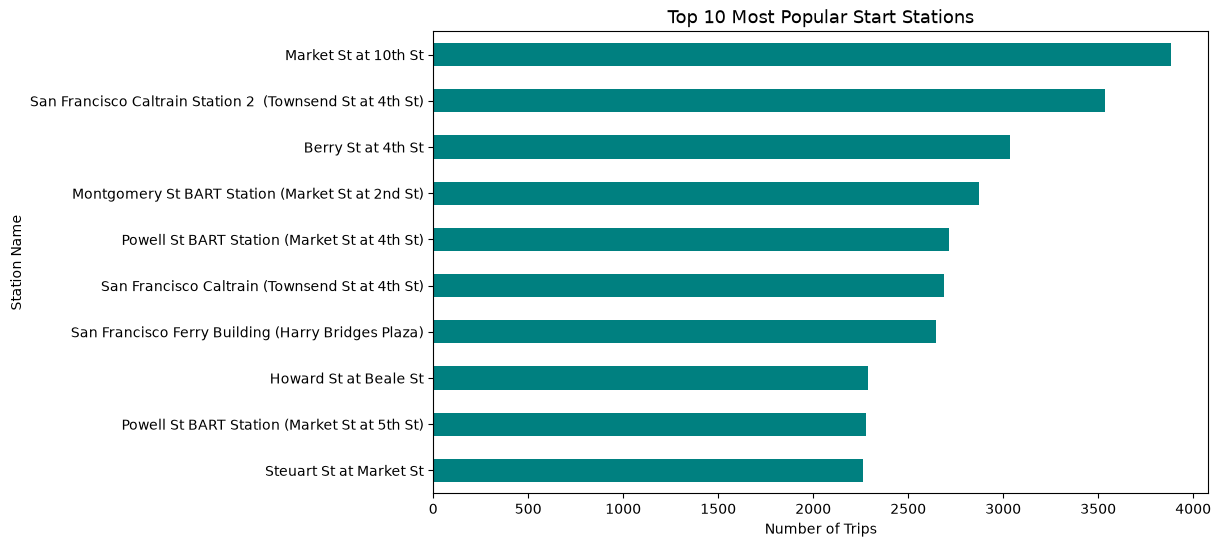

In [13]:
plt.figure(figsize=(10, 6))
df['start_station_name'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Popular Start Stations', fontsize=13)
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.gca().invert_yaxis()
plt.show()

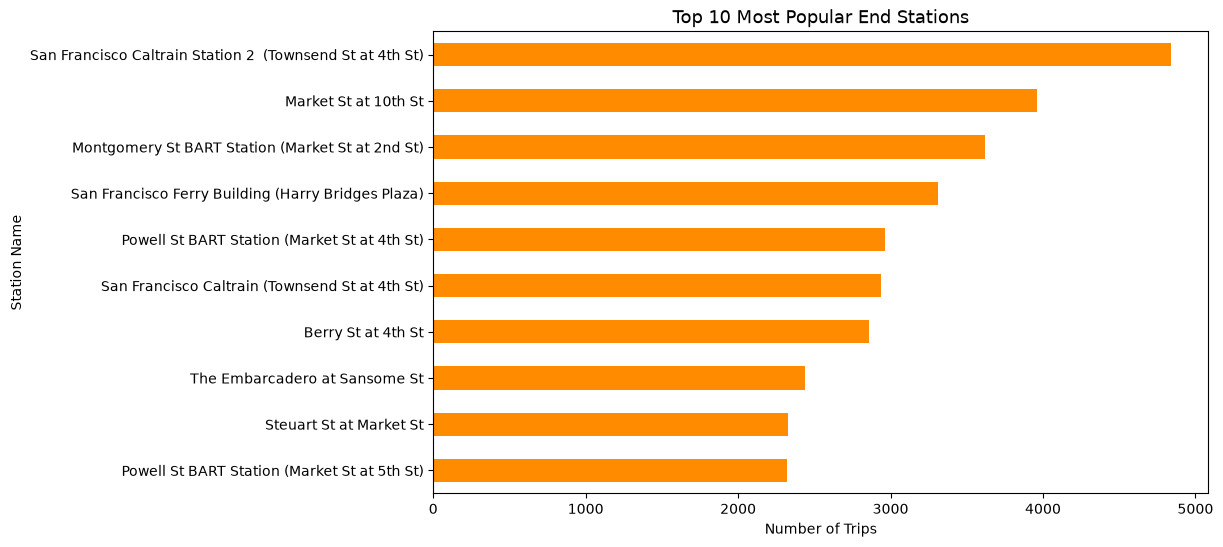

In [14]:
plt.figure(figsize=(10, 6))
df['end_station_name'].value_counts().head(10).plot(kind='barh', color='darkorange')
plt.title('Top 10 Most Popular End Stations', fontsize=13)
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.gca().invert_yaxis()
plt.show()

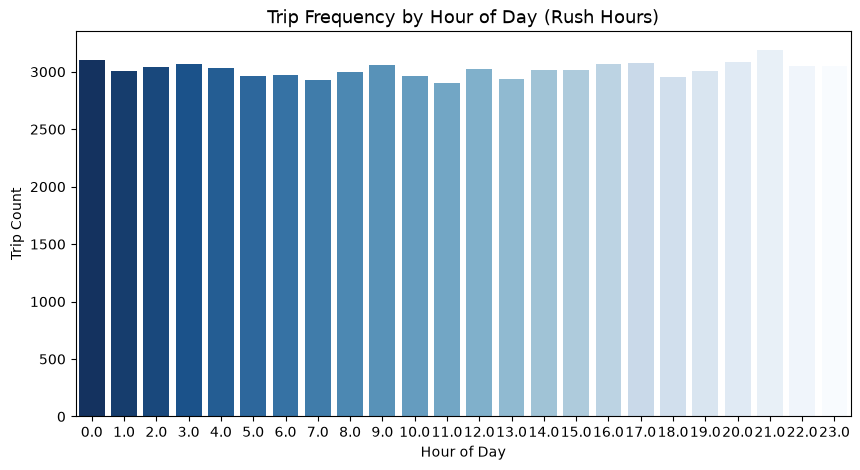

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='start_hour', hue='start_hour', legend=False, palette='Blues_r')
plt.title('Trip Frequency by Hour of Day (Rush Hours)', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Trip Count')
plt.show()
